#**African Farm-Led Irrigation System**

Team 01: Linh Le, Tae Yoon Kim, Juncheng Zhu, Bill

# Load Data & Packages

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

In [37]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2023/2023-06-13/safi_data.csv"
safi = pd.read_csv(url)

In [38]:
print("Shape:", safi.shape)
safi.head()

Shape: (131, 14)


,key_ID,village,interview_date,no_membrs,years_liv,respondent_wall_type,rooms,memb_assoc,affect_conflicts,liv_count,items_owned,no_meals,months_lack_food,instanceID
0,1,God,2016-11-17T00:00:00Z,3,4,muddaub,1,NaN,NaN,1,bicycle;television;solar_panel;table,2,Jan,uuid:ec241f2c-0609-46ed-b5e8-fe575f6cefef
1,1,God,2016-11-17T00:00:00Z,7,9,muddaub,1,yes,once,3,cow_cart;bicycle;radio;cow_plough;solar_panel;...,2,Jan;Sept;Oct;Nov;Dec,uuid:099de9c9-3e5e-427b-8452-26250e840d6e
2,3,God,2016-11-17T00:00:00Z,10,15,burntbricks,1,NaN,NaN,1,solar_torch,2,Jan;Feb;Mar;Oct;Nov;Dec,uuid:193d7daf-9582-409b-bf09-027dd36f9007
3,4,God,2016-11-17T00:00:00Z,7,6,burntbricks,1,NaN,NaN,2,bicycle;radio;cow_plough;solar_panel;mobile_phone,2,Sept;Oct;Nov;Dec,uuid:148d1105-778a-4755-aa71-281eadd4a973
4,5,God,2016-11-17T00:00:00Z,7,40,burntbricks,1,NaN,NaN,4,motorcyle;radio;cow_plough;mobile_phone,2,Aug;Sept;Oct;Nov,uuid:2c867811-9696-4966-9866-f35c3e97d02d


Feature Engineering

In [39]:
# Clean categorical
for c in ["memb_assoc","affect_conflicts"]:
    safi[c] = safi[c].fillna("unknown").str.lower().str.strip()

# Food insecurity count
safi["months_lack_food_count"] = (
    safi["months_lack_food"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: len([m for m in x if m.strip() not in ["none",""]]))
)

# Asset count
safi["items_owned_count"] = (
    safi["items_owned"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: len([i for i in x if i.strip() != ""]))
)


Numeric Feature Set (Used Across Methods)

In [40]:
features = [
    "no_membrs",
    "liv_count",
    "rooms",
    "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count"
]

X = safi[features].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##EDA

In [41]:
#Distributions (for every clustering feature)
cluster_features = [
    "no_membrs",
    "liv_count",
    "rooms", "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count"
]

cluster_features = [c for c in cluster_features if c in safi.columns]

safi[cluster_features].describe()

,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
count,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,7.19084,2.366412,1.740458,2.603053,2.320611,23.053435,4.740458
std,3.17227,1.082775,1.092547,0.491143,1.997179,16.913041,3.153966
min,2.00000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000
25%,5.00000,1.000000,1.000000,2.000000,0.000000,12.000000,2.000000
50%,7.00000,2.000000,1.000000,3.000000,2.000000,20.000000,5.000000
75%,9.00000,3.000000,2.000000,3.000000,3.000000,27.500000,7.000000
max,19.00000,5.000000,8.000000,3.000000,11.000000,96.000000,15.000000


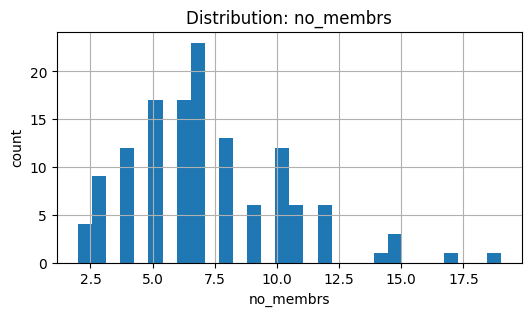

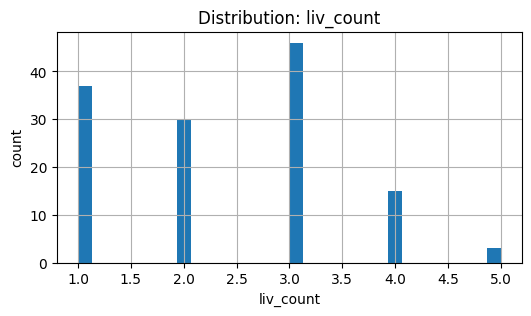

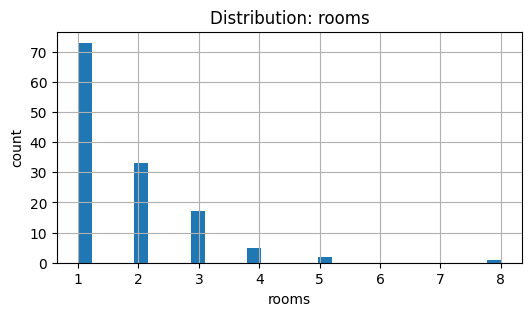

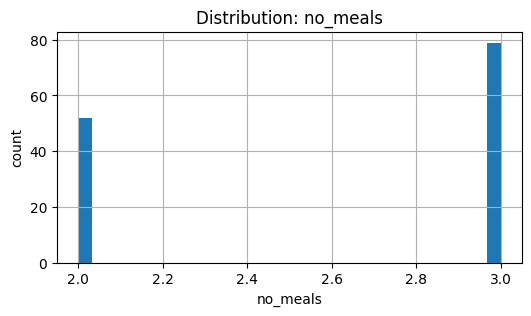

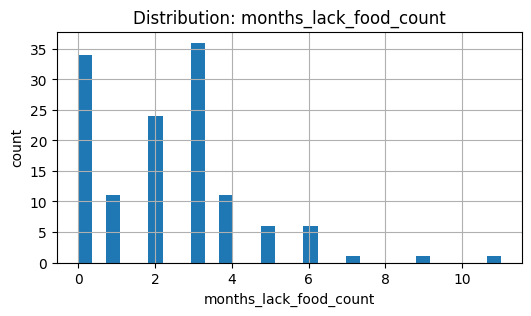

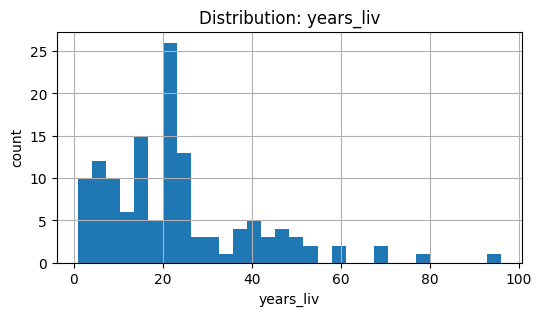

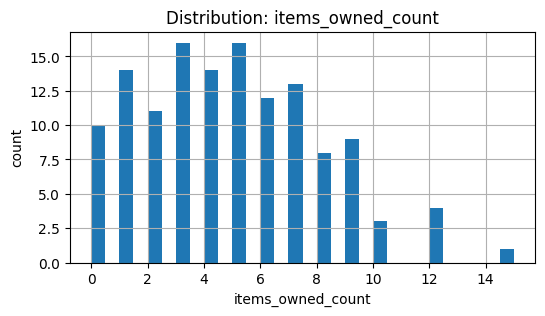

In [42]:
for c in cluster_features:
    plt.figure(figsize=(6,3))
    safi[c].hist(bins=30)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

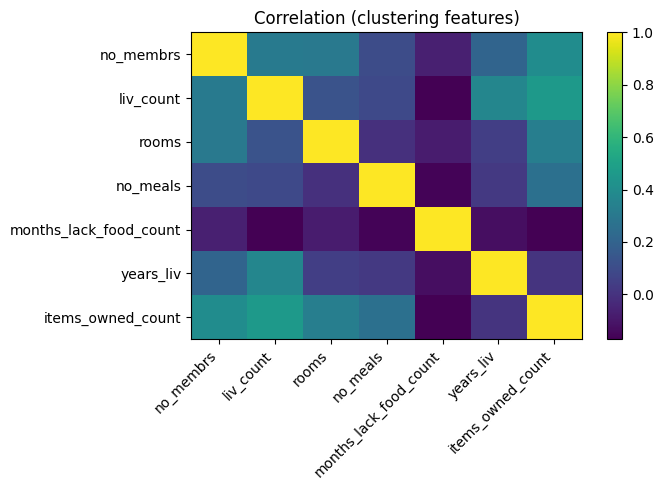

In [43]:
#Correlation heatmap
corr = safi[cluster_features].corr(numeric_only=True)

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation (clustering features)")
plt.tight_layout()
plt.show()

In [44]:
# Group comparisons (membership/village vs features)
if "memb_assoc" in safi.columns:
    display(safi.groupby("memb_assoc")[cluster_features].mean(numeric_only=True))

if "village" in safi.columns:
    display(safi.groupby("village")[cluster_features].mean(numeric_only=True).head(10))

,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
memb_assoc,,,,,,,
no,7.406780,2.525424,1.745763,2.610169,2.000000,22.406780,5.152542
unknown,5.769231,1.897436,1.692308,2.538462,2.820513,20.128205,3.487179
yes,8.484848,2.636364,1.787879,2.666667,2.303030,27.666667,5.484848


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
village,,,,,,,
Chirodzo,7.076923,2.256410,1.974359,2.615385,2.102564,23.615385,4.538462
God,6.860465,2.232558,1.534884,2.558140,3.000000,20.418605,3.976744
Ruaca,7.571429,2.571429,1.734694,2.632653,1.897959,24.918367,5.571429


##Gower

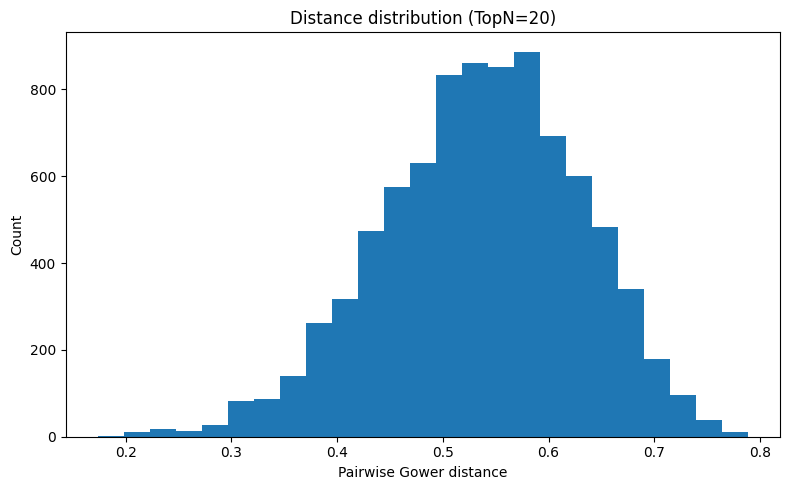

In [45]:
def gower_distance(df, feature_cols=None, exclude_cols=None):
    """
    Compute NxN Gower distance matrix directly from a mixed-type DataFrame.

    Rules:
      - numeric: min-max scaled to [0,1], distance = |xi-xj|
      - categorical: mismatch (0/1)
      - binary (bool or {0,1}): abs diff (0/1)
    Missing handling:
      - numeric -> median
      - categorical -> "Missing"
      - binary -> 0

    Params
    ------
    df : pd.DataFrame
    feature_cols : list or None
        If provided, only these columns are used.
    exclude_cols : list or None
        Columns to drop (e.g., IDs).

    Returns
    -------
    D : np.ndarray shape (n, n)
    """
    dfw = df.copy()

    if feature_cols is not None:
        dfw = dfw[feature_cols].copy()
    if exclude_cols is not None:
        dfw = dfw.drop(columns=[c for c in exclude_cols if c in dfw.columns], errors="ignore")

    if dfw.shape[1] == 0:
        raise ValueError("No columns left to compute Gower distance.")

    cat_cols = dfw.select_dtypes(include=["object", "category"]).columns.tolist()
    num_bool_cols = dfw.select_dtypes(include=[np.number, "bool"]).columns.tolist()

    def is_binary(s: pd.Series) -> bool:
        if s.dtype == bool:
            return True
        if not pd.api.types.is_numeric_dtype(s):
            return False
        u = pd.Series(s.dropna().unique())
        if len(u) == 0:
            return False
        try:
            u = set(u.astype(float).tolist())
        except Exception:
            return False
        return u.issubset({0.0, 1.0}) and len(u) <= 2

    bin_cols, num_cols = [], []
    for c in num_bool_cols:
        (bin_cols if is_binary(dfw[c]) else num_cols).append(c)

    for c in num_cols:
        if dfw[c].isna().any():
            med = dfw[c].median()
            if pd.isna(med):
                med = 0.0
            dfw[c] = dfw[c].fillna(med)

    for c in cat_cols:
        dfw[c] = dfw[c].astype("object").fillna("Missing")

    for c in bin_cols:
        dfw[c] = dfw[c].fillna(0).astype(int)

    Xn = np.empty((len(dfw), 0), dtype=float)
    if num_cols:
        Xn_df = pd.DataFrame(index=dfw.index)
        for c in num_cols:
            x = dfw[c].astype(float)
            mn, mx = float(x.min()), float(x.max())
            if mx == mn:
                Xn_df[c] = 0.0
            else:
                Xn_df[c] = (x - mn) / (mx - mn)
        keep = [c for c in Xn_df.columns if Xn_df[c].nunique(dropna=False) > 1]
        Xn = Xn_df[keep].to_numpy(dtype=float) if keep else np.empty((len(dfw), 0), dtype=float)

    Xc = np.empty((len(dfw), 0), dtype=int)
    if cat_cols:
        Xc_df = pd.DataFrame(index=dfw.index)
        for c in cat_cols:
            codes = pd.Categorical(dfw[c]).codes.astype(int)
            if len(np.unique(codes)) > 1:
                Xc_df[c] = codes
        Xc = Xc_df.to_numpy(dtype=int) if Xc_df.shape[1] else np.empty((len(dfw), 0), dtype=int)

    Xb = np.empty((len(dfw), 0), dtype=int)
    if bin_cols:
        Xb_df = dfw[bin_cols].astype(int)
        keep = [c for c in Xb_df.columns if Xb_df[c].nunique(dropna=False) > 1]
        Xb = Xb_df[keep].to_numpy(dtype=int) if keep else np.empty((len(dfw), 0), dtype=int)

    p = Xn.shape[1] + Xc.shape[1] + Xb.shape[1]
    if p == 0:
        raise ValueError("All selected columns are constant after preprocessing; no usable features.")

    n = len(dfw)
    D = np.zeros((n, n), dtype=float)

    for i in range(n):
        dn = np.abs(Xn[i] - Xn).sum(axis=1) if Xn.shape[1] else 0.0
        dc = (Xc[i] != Xc).astype(float).sum(axis=1) if Xc.shape[1] else 0.0
        db = np.abs(Xb[i] - Xb).sum(axis=1) if Xb.shape[1] else 0.0
        D[i] = (dn + dc + db) / p

    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    return D

D = gower_distance(safi, exclude_cols=["hhid","id"])

upper = D[np.triu_indices_from(D, k=1)]

plt.figure(figsize=(8, 5))
plt.hist(upper, bins=25)
plt.xlabel("Pairwise Gower distance")
plt.ylabel("Count")
plt.title("Distance distribution (TopN=20)")
plt.tight_layout()
plt.show()

##KMeans — Elbow + Silhouette

Elbow

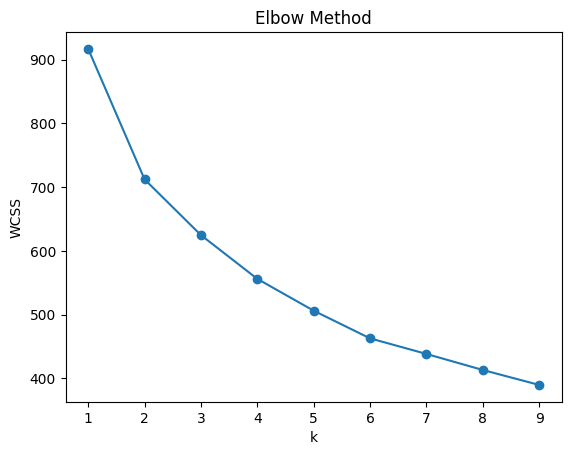

In [46]:
wcss = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

Silhouette

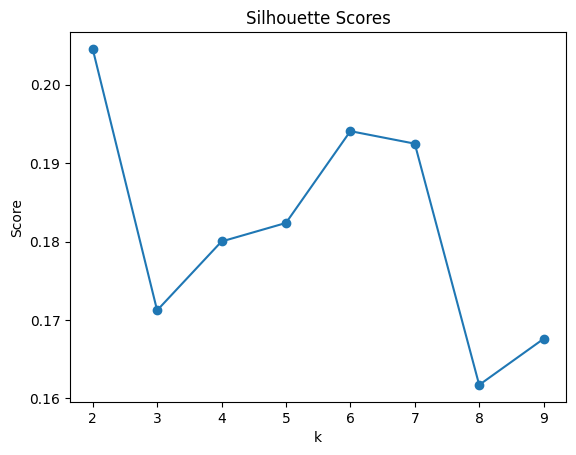

In [47]:
sil_scores = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,10), sil_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

Silhouette is highest at k=2, but that solution is overly coarse; k=4 provides a more interpretable segmentation while remaining near the elbow region.

Fit Final KMeans

In [48]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
safi["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

##Hierarchical Cluster

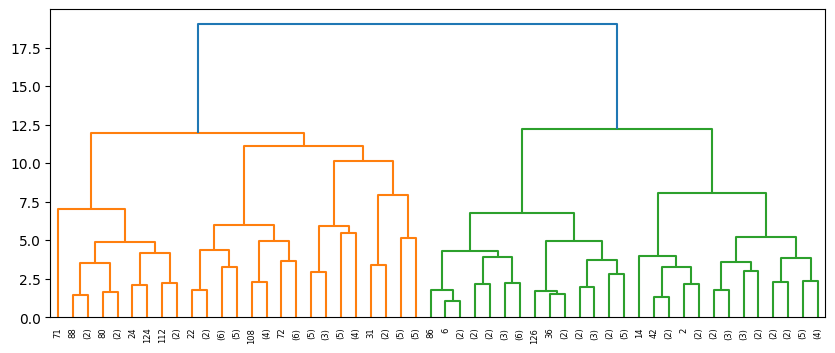

In [49]:
Z = linkage(X_scaled, method="ward")  # ward is common for continuous numeric data

plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="level", p=5)
plt.show()

safi["hier_cluster"] = fcluster(Z, t=best_k, criterion="maxclust")

Improved Outlier Detection (distance-to-centroid)

In [50]:
centroids = kmeans.cluster_centers_
labels = safi["kmeans_cluster"].values

distances = np.linalg.norm(X_scaled - centroids[labels], axis=1)
safi["distance_to_centroid"] = distances

safi["distance_z"] = (
    safi.groupby("kmeans_cluster")["distance_to_centroid"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

safi["economic_outlier"] = safi["distance_z"] > 2

##PCA Visualization

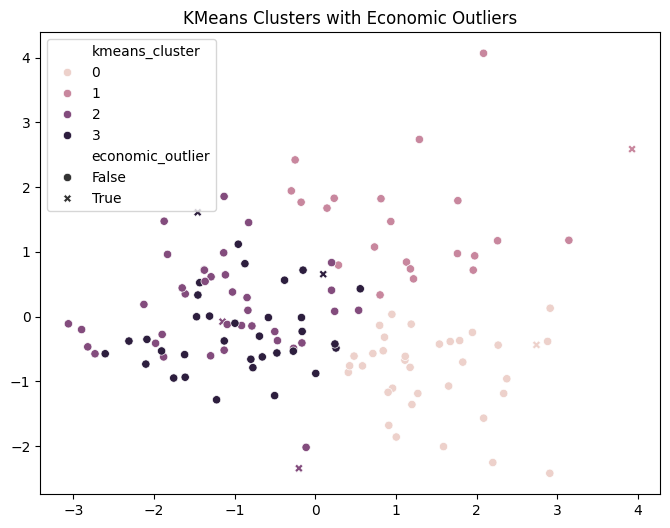

In [51]:
coords = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=coords[:,0],
    y=coords[:,1],
    hue=safi["kmeans_cluster"],
    style=safi["economic_outlier"]
)
plt.title("KMeans Clusters with Economic Outliers")
plt.show()

##Isolation Forest

In [52]:
safi["months_lack_food_count"] = (
    safi["months_lack_food"]
    .fillna("unknown")
    .str.lower()
    .str.strip()
    .apply(lambda x: 0 if x == "unknown" else len(x.split(";")))
)

safi["items_owned_count"] = (
    safi["items_owned"]
    .fillna("")
    .apply(lambda x: len(x.split(";")) if x else 0)
)

features = [
    "no_membrs",
    "liv_count",
    "rooms",
    "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count",
]

X = safi[features].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
safi["is_anomalous"] = iso.fit_predict(X_scaled) == -1

n_anomalous = safi["is_anomalous"].sum()
print(f"Anomalous households: {n_anomalous}")

Anomalous households: 13


In [54]:
import umap

embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)
safi["umap_x"] = embedding[:, 0]
safi["umap_y"] = embedding[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


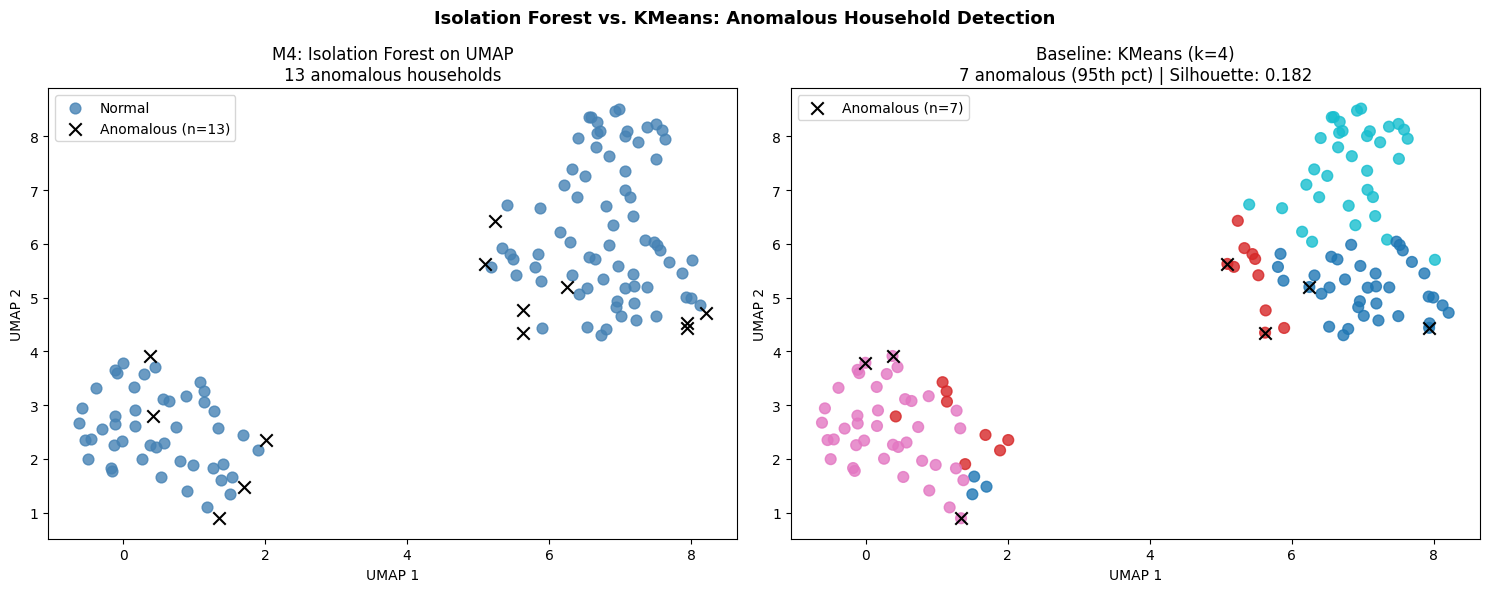

In [55]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
safi["kmeans_cluster"] = km_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

normal = ~safi["is_anomalous"]
axes[0].scatter(safi.loc[normal, "umap_x"], safi.loc[normal, "umap_y"],
                c='steelblue', s=60, alpha=0.8, label='Normal')
axes[0].scatter(safi.loc[safi["is_anomalous"], "umap_x"],
                safi.loc[safi["is_anomalous"], "umap_y"],
                c='black', s=80, marker='x', linewidths=1.5,
                label=f'Anomalous (n={n_anomalous})')
axes[0].set_title(f"M4: Isolation Forest on UMAP\n{n_anomalous} anomalous households")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].legend()

centroids = kmeans.cluster_centers_
distances = np.linalg.norm(X_scaled - centroids[km_labels], axis=1)
km_outlier = distances > np.percentile(distances, 95)
axes[1].scatter(safi["umap_x"], safi["umap_y"],
                c=km_labels, cmap='tab10', s=60, alpha=0.8)
axes[1].scatter(safi.loc[km_outlier, "umap_x"],
                safi.loc[km_outlier, "umap_y"],
                c='black', s=80, marker='x', linewidths=1.5,
                label=f'Anomalous (n={km_outlier.sum()})')
axes[1].set_title(f"Baseline: KMeans (k=4)\n{km_outlier.sum()} anomalous (95th pct) | Silhouette: {km_sil:.3f}")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.suptitle("Isolation Forest vs. KMeans: Anomalous Household Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()